<a href="https://colab.research.google.com/github/elithecreator06/machine-learning-algorithms/blob/main/kmeans-pca-clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#PART 1
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load Boston Housing Data
data_url = "http://lib.stat.cmu.edu/datasets/boston"

#Read the dataset into a DataFrame
raw_df = pd.read_csv(
    data_url,
    sep = r"\s+",
    skiprows = 22,
    header = None
)

#Combine Rows to create the feature matrix
data = np.hstack([
    raw_df.values[::2, :],
    raw_df.values[1::2, :2]
])

target = raw_df.values[1::2, 2]

#Feature names
columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

df = pd.DataFrame(data, columns = columns)

#Reverse RAD column
df = df.drop('RAD', axis = 1)

x = df.values

In [ ]:
#Standardise features so each contributes equally
x = (x - np.mean(x, axis = 0)) / np.std(x, axis = 0)

In [ ]:
#K-Means clustering algorithm implemented
def kmeans(x, k = 4, max_iters = 100):
  np.random.seed(42)

  #Randomly select intitial centroids
  random_idx = np.random.choice(len(x), k, replace = False)
  centroids = x[random_idx]

  for _ in range(max_iters):
    distances = np.linalg.norm(
        x[:, np.newaxis] - centroids,
        axis = 2
    )

    #Assign each point to the neaarst centroid
    labels = np.argmin(distances, axis = 1)

    #Update centroid locations
    new_centroids = np.array([
        x[labels == i].mean(axis = 0)
        for i in range (k)
    ])

    #Stop if centroids no longer change
    if np.allclose(centroids, new_centroids):
      break

    centroids = new_centroids

  return labels, centroids

In [ ]:
#Create 4 cluster using K-Means
labels, centroids = kmeans(x, k = 4)

#Display cluster labels
print("Cluster created: ", np.unique(labels))

Cluster created:  [0 1 2 3]


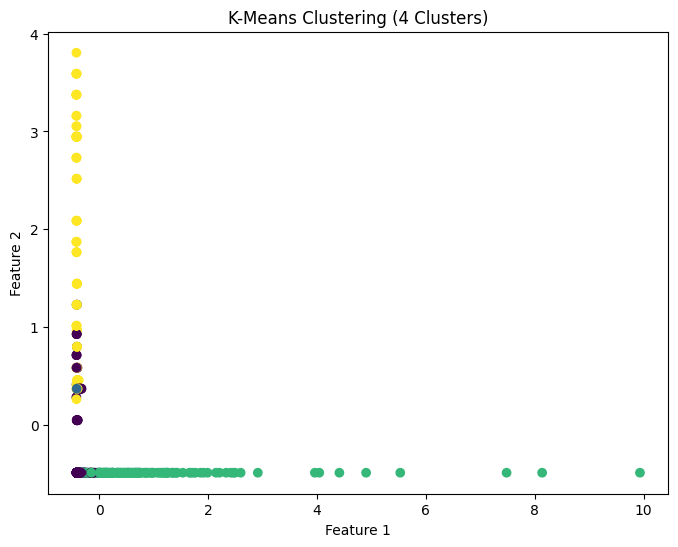

In [ ]:
#Visualise clustering results using the first two features
plt.figure(figsize = (8,6))

plt.scatter(
    x[:, 0],
    x[:, 1],
    c = labels,
    cmap = 'viridis'
)

plt.title("K-Means Clustering (4 Clusters)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [ ]:
#PART 2
#Principal Component Analysis implemented
def pca(x, n_components):
  x_centered = x - np.mean(x, axis = 0)
  cov_matrix = np.cov(x_centered.T)
  eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
  idx = np.argsort(eigenvalues)[::-1]
  eigenvectors = eigenvectors[:, idx]
  components = eigenvectors[:, :n_components]
  return np.dot(x_centered, components)

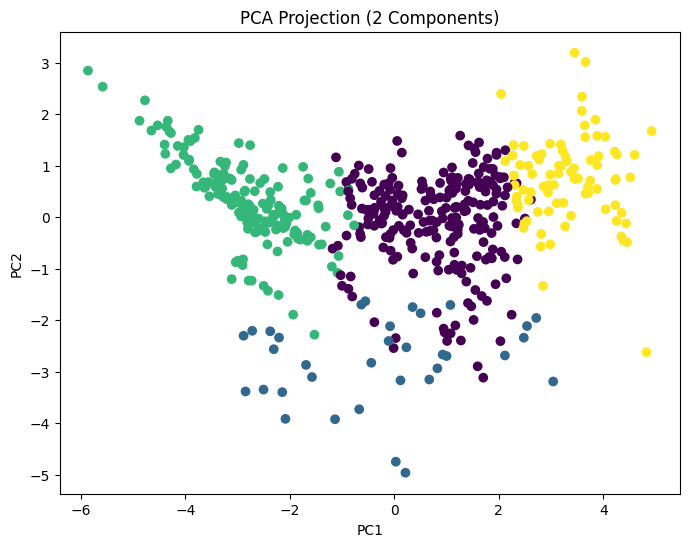

In [ ]:
#Reduce dataset to two principle components
x_pca2 = pca(x, 2)

#Create 2D PCA visualisation
plt.figure(figsize = (8,6))

plt.scatter(
    x_pca2[:, 0],
    x_pca2[:, 1],
    c = labels,
    cmap = 'viridis'
)

plt.title("PCA Projection (2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

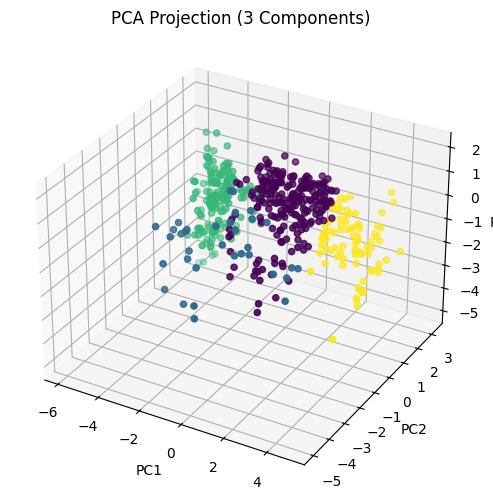

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

#Reduce dataset to three principal components
x_pca3 = pca(x, 3)
fig = plt.figure(figsize = (8,6))

#Create 3D PCA visualisation
ax = fig.add_subplot(111, projection = '3d')

scatter = ax.scatter(
    x_pca3[:, 0],
    x_pca3[:, 1],
    x_pca3[:, 2],
    c = labels,
    cmap = 'viridis'
)

ax.set_title("PCA Projection (3 Components)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()

The 2-dimensional PCA projection provides a simplified view of the Boston Housing dataset by preserving the two directions with the greatest variance. The four clusters can be observed, but some overlap exists between groups because information is lost when reducing the data to only two dimensions.

The 3-dimensional PCA projection preserves more of the original variance by including a third principal component. As a result, the cluster structure becomes easier to distinguish and the separation between groups is generally clearer. The additional dimension provides more information about the underlying data distribution.

Overall, the 3D PCA representation offers a better visualisation of the cluster relationship, while the 2D PCA representation is easier to interpret and display.